# ftir_54 — Model-form robustness: does the Addis result depend on PLS?

## tl;dr

**The Addis result does not depend on PLS, and nothing nonlinear beats PLS anywhere it can
be scored.** Five model forms (PLS, histogram gradient boosting, random forest, MLP,
PLS-scores → boosting) on the locked lowest-OC/EC 800 cohort, the same site-disjoint
protocol split, corrected spectra: held-out IMPROVE R² is PLS 0.904 against 0.77 (HGB),
0.73 (RF), 0.53 (MLP), 0.77 (hybrid); on the second-derivative representation the random
forest reaches 0.909 vs PLS 0.916, and on the full 13,010-filter pool everything is worse
and PLS is still first (0.66). **Every model form puts the Addis intercept below zero**:
−1.62 (locked PLS), −4.08 (HGB, 1.63x), −3.40 (RF, 1.39x), −1.63 (MLP), −1.21 (hybrid);
the derivative and full-pool runs span −0.6 to −2.9. The tree models on corrected
spectra land where the *raw* PLS model used to (≈1.5x, −3 to −4) — no architecture finds
a zero intercept. **Where extrapolation can be scored with labels (inside IMPROVE), PLS
extrapolates best**: on the 800 lowest-OC/EC filters held out from the rest of the
network all forms under-predict by 3–4 µg with slope ≈0.3 and PLS has the lowest RMSE
(12.2 vs 12.5–13.7); on the top-5% spectral-distance slice PLS keeps slope 0.81 (RMSE 18)
while the trees collapse to 0.2–0.3 (RMSE 24–25); on the top-5% loading slice the trees
saturate completely (slope 0.01–0.02, R² ≈ 0) while PLS keeps 0.36. **Diagnosability**:
Addis is inside the 800-cohort training envelope by both D² (4% beyond the PCA p95, 0.5%
beyond the PLS p95, as ftir_39 found), the corrected PLS residual is independent of D²
(ρ 0.02 — the ftir_15 constant-offset result reproduces), the tree residuals *do* track
D² (ρ 0.30–0.38) but the trees carry no internal flag: random-forest spread correlates
with PCA D² at only ρ 0.36. The model-agnostic PCA D² works for any form, so the
legibility argument is really about saturation (test C), not about the availability of a
distance. Verdict: keep PLS; cite this notebook as "the negative Addis intercept is
model-form independent"; do not spend more time on architectures.

## Why this notebook exists

Every phase-3 calibration is a PLS model. The question raised on 2026-09-01 was whether
a nonlinear learner (gradient boosting, random forest, a small neural network) trained
on the same IMPROVE spectra would (a) fit the network better, (b) land somewhere else on
Addis, and (c) be as diagnosable off-domain as PLS is with score-space D². This notebook
is the cheap experiment: same cohorts, same site-disjoint protocol split, same Addis
evaluation, several model forms side by side. It is a **robustness check on the locked
result, not a replacement search** — the Addis question is physics (MAC, pyrolysis,
composition), and no architecture answers it without Addis labels.

## Design

- **Cohorts:** the locked lowest-OC/EC 800 cohort (ftir_11) and the full IMPROVE pool
  with a positive TOR EC loading (n ≈ 13,000, 158 sites). Both on AIRSpec-corrected
  spectra (df1=6, df2=4), the locked representation; the 800 cohort is also run on the
  Savitzky–Golay second derivative, the representation usually paired with tree models.
- **Split:** the locked `site_heldout` protocol split (`protocol_train_mask`, seed
  20260717, site-disjoint 80/20). Every model form sees exactly the same rows.
- **Model forms:** PLS (protocol first-major-minimum k), histogram gradient boosting
  (HGB, the scikit-learn analogue of LightGBM), random forest, a one-hidden-layer MLP on
  standardized spectra, and a hybrid PLS-scores → HGB (nonlinearity on top of PLS's
  compressed space). HGB hyperparameters are chosen once by site-grouped CV on the 800
  cohort and carried unchanged to the full pool; nothing is tuned on Addis.
- **Addis:** the 190-filter fixed evaluation set (filters with a deployed EC), scored
  against HIPS Fabs/10 with `regression_metrics`, exactly as in ftir_44.
- **Labelled extrapolation tests (the part Addis cannot give us):** three holdouts inside
  IMPROVE where the truth is known — (A) the 800 lowest-OC/EC filters held out from the
  rest of the network (compositional extrapolation without site shift), (B) the 5% of
  filters farthest from the pool in PCA score space (spectral-edge extrapolation), and
  (C) the 5% highest EC loadings (range extrapolation).
- **Diagnosability:** for each model, Addis residual and prediction against a
  model-agnostic D² (PCA-10 score space of the training spectra, Ledoit–Wolf covariance,
  as in ftir_39), plus PLS's own score-space D² and the random forest's tree spread.

In [1]:
%matplotlib inline
import sys
import time
import warnings
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import savgol_filter
from scipy.stats import spearmanr
from sklearn.covariance import LedoitWolf
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from calibration_modes import fit_calibration, protocol_train_mask
from phase3_common import PATHS, load_addis_evaluation, load_pool_metadata
from pls_transfer import regression_metrics
from plotting import apply_default_style

warnings.filterwarnings('ignore', category=UserWarning)
apply_default_style()
OUT = Path('output/tables/ftir54')
PLOTS = Path('output/plots/ftir54')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

MODE = 'site_heldout'
MAC = 10.0
SEED = 20260717
COLORS = {'PLS': '#8E44AD', 'HGB': '#E67E22', 'RF': '#27AE60', 'MLP': '#3498DB',
          'PLS→HGB': '#C0392B'}

## Data

### Provenance

The IMPROVE pool is the AIRSpec-corrected library written by ftir_13
(`output/corrected/improve_pool_corrected_df6.npz`), joined to TOR loadings from the
local database exactly as in ftir_44. The 800 cohort is the OC/EC-sorted file from
ftir_11. Addis spectra are the corrected ETAD scans averaged per physical filter; the
evaluation set is the 190 filters with a deployed EC (the phase-2 fixed cohort).

In [2]:
corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
wn = corrected_npz['wn'].astype(float)
corrected_row = {int(a): i for i, a in enumerate(corrected_npz['analysis_id'].astype(int))}

tor = pd.read_csv(PATHS.ftir_dir / 'local_db/tables/results_tor.csv',
                  usecols=['Site', 'SampleDate', 'Parameter', 'Value', 'AverageFlowRate', 'ElapsedTime'])
tor['date'] = pd.to_datetime(tor['SampleDate'], format='mixed', errors='coerce').dt.normalize()
tor['loading_ug'] = tor['Value'] * (tor['AverageFlowRate'] / 1000 * tor['ElapsedTime']) / 1000
wide = (tor.pivot_table(index=['Site', 'date'], columns='Parameter', values='loading_ug', aggfunc='first')
        .rename(columns={'EC': 'EC_TOR', 'OC': 'OC_TOR'}).reset_index())
pool_meta = load_pool_metadata()
pool_meta['AnalysisId'] = pool_meta['AnalysisId'].astype(int)
pool = (pool_meta.merge(wide, on=['Site', 'date'], how='inner', validate='many_to_one')
        .drop_duplicates('FilterId').drop_duplicates('AnalysisId'))
pool = pool[pool['AnalysisId'].isin(corrected_row)].set_index('AnalysisId')
pool = pool[pool['EC_TOR'] > 0]

ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')
assert ocec['OC_EC_ratio'].is_monotonic_increasing
ids_800 = np.array([i for i in ocec['AnalysisId'].astype(int) if i in pool.index])
ids_full = pool.index.to_numpy()

etad_eval, _, _ = load_addis_evaluation()
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis = etad_corr.groupby('MediaId').mean().loc[etad_eval['MediaId'].astype(int)].to_numpy(float)
fabs_addis = etad_eval['Fabs'].to_numpy(float)
volume_addis = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()
hips_ec = fabs_addis / MAC


def spectra_for(ids):
    return corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)


def deriv2(X):
    return savgol_filter(np.asarray(X, float), window_length=11, polyorder=2, deriv=2, axis=1)


print(f'pool with EC_TOR>0: {len(ids_full)} filters, {pool["Site"].nunique()} sites; '
      f'locked 800 cohort → {len(ids_800)}; Addis evaluation {fixed_mask.sum()} of {len(etad_eval)} filters')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
pool with EC_TOR>0: 13010 filters, 158 sites; locked 800 cohort → 800; Addis evaluation 190 of 239 filters


## Model forms

Each `make_*` returns an unfitted estimator with `fit(X, y)` / `predict(X)`. The hybrid
fits PLS with the protocol's own k on the training rows and then boosts on the scores.
HGB hyperparameters are selected below by site-grouped 3-fold CV on the 800 cohort only
(learning rate × leaf count; L2 fixed at 1, 300 iterations).

In [3]:
class PLSThenHGB:
    """PLS scores (protocol k) → histogram gradient boosting."""

    def __init__(self, k, **hgb):
        self.k = k
        self.hgb = HistGradientBoostingRegressor(**hgb)

    def fit(self, X, y):
        self.pls = PLSRegression(n_components=self.k, scale=False).fit(X, y)
        self.hgb.fit(self.pls.transform(X), y)
        return self

    def predict(self, X):
        return self.hgb.predict(self.pls.transform(X))


def make_models(k_pls, hgb_params):
    return {
        'PLS': PLSRegression(n_components=k_pls, scale=False),
        'HGB': HistGradientBoostingRegressor(random_state=0, **hgb_params),
        'RF': RandomForestRegressor(n_estimators=300, max_features='sqrt', min_samples_leaf=2,
                                    n_jobs=-1, random_state=0),
        'MLP': make_pipeline(StandardScaler(),
                             MLPRegressor(hidden_layer_sizes=(64,), alpha=1e-2, max_iter=500,
                                          early_stopping=True, random_state=0)),
        'PLS→HGB': PLSThenHGB(k_pls, random_state=0, **hgb_params),
    }

In [4]:
X_800 = spectra_for(ids_800)
y_800 = pool.loc[ids_800, 'EC_TOR'].to_numpy(float)
s_800 = pool.loc[ids_800, 'Site'].to_numpy()
train_800 = protocol_train_mask(MODE, X_800, y_800, s_800)

grid = [{'learning_rate': lr, 'max_leaf_nodes': leaves, 'max_iter': 300, 'l2_regularization': 1.0}
        for lr in (0.05, 0.1) for leaves in (7, 15, 31)]
gkf = GroupKFold(n_splits=3)
tune_rows = []
for params in grid:
    errors = []
    for tr, te in gkf.split(X_800[train_800], y_800[train_800], groups=s_800[train_800]):
        m = HistGradientBoostingRegressor(random_state=0, **params).fit(X_800[train_800][tr], y_800[train_800][tr])
        errors.append(np.sqrt(np.mean((m.predict(X_800[train_800][te]) - y_800[train_800][te]) ** 2)))
    tune_rows.append({**params, 'rmsecv_ug': float(np.mean(errors))})
tune = pd.DataFrame(tune_rows).sort_values('rmsecv_ug').reset_index(drop=True)
tune.to_csv(OUT / 'hgb_grouped_cv_tuning_800.csv', index=False)
HGB_PARAMS = {k: tune.iloc[0][k] for k in ('learning_rate', 'max_leaf_nodes', 'l2_regularization')}
HGB_PARAMS['max_leaf_nodes'] = int(HGB_PARAMS['max_leaf_nodes'])
HGB_PARAMS['max_iter'] = 300
display(tune.head(6).round(3))
print('HGB parameters carried forward:', HGB_PARAMS)

,learning_rate,max_leaf_nodes,max_iter,l2_regularization,rmsecv_ug
0,0.05,7,300,1.0,13.605
1,0.05,15,300,1.0,13.629
2,0.05,31,300,1.0,13.643
3,0.10,15,300,1.0,14.385
4,0.10,7,300,1.0,14.392
5,0.10,31,300,1.0,14.416


HGB parameters carried forward: {'learning_rate': np.float64(0.05), 'max_leaf_nodes': 7, 'l2_regularization': np.float64(1.0), 'max_iter': 300}


## 1. Same protocol, five model forms, two cohorts

For each cohort × representation the PLS k comes from the locked protocol rule
(`fit_calibration`), the held-out score is on the protocol's untouched sites, and the
Addis metrics are the 190-filter crossplot against Fabs/10.

In [5]:
def pca_d2(X_train, X_query, n_components=10):
    """Model-agnostic Mahalanobis D² in a PCA-10 score space fitted on training spectra."""
    scaler = StandardScaler().fit(X_train)
    pca = PCA(n_components=n_components, random_state=0).fit(scaler.transform(X_train))
    T_train = pca.transform(scaler.transform(X_train))
    T_query = pca.transform(scaler.transform(X_query))
    cov = LedoitWolf().fit(T_train)
    return cov.mahalanobis(T_train), cov.mahalanobis(T_query)


def pls_d2(model, X_train, X_query):
    """PLS's own score-space D² (ftir_15/ftir_30 definition)."""
    T_train = model.transform(X_train)
    cov_inv = np.linalg.inv(np.cov(T_train.T))
    centre = T_train.mean(axis=0)

    def d2(scores):
        d = scores - centre
        return np.einsum('ij,jk,ik->i', d, cov_inv, d)
    return d2(T_train), d2(model.transform(X_query))


def run_family(label, ids, rep, k_override=None):
    X = spectra_for(ids)
    Xa = X_addis
    if rep == 'deriv2':
        X, Xa = deriv2(X), deriv2(X_addis)
    y = pool.loc[ids, 'EC_TOR'].to_numpy(float)
    sites = pool.loc[ids, 'Site'].to_numpy()
    train = protocol_train_mask(MODE, X, y, sites)
    pls_fit = fit_calibration(MODE, label, X, y, sites, Xa, volume_addis, k_override=k_override)
    k = pls_fit.k
    d2_train_pca, d2_addis_pca = pca_d2(X[train], Xa)
    p95_pca = float(np.quantile(d2_train_pca, .95))
    rows, preds = [], {}
    for name, model in make_models(k, HGB_PARAMS).items():
        t0 = time.time()
        model.fit(X[train], y[train])
        held = regression_metrics(y[~train], model.predict(X[~train]).ravel())
        addis = model.predict(Xa).ravel() / volume_addis
        cross = regression_metrics(hips_ec[fixed_mask], addis[fixed_mask])
        resid = addis[fixed_mask] - hips_ec[fixed_mask]
        rho_pca = spearmanr(d2_addis_pca[fixed_mask], resid).statistic
        rho_pred_pca = spearmanr(d2_addis_pca[fixed_mask], addis[fixed_mask]).statistic
        row = {'cohort': label, 'representation': rep, 'model': name, 'k_pls': k,
               'n_train': int(train.sum()), 'n_heldout': int((~train).sum()),
               'heldout_R2': held['R2'], 'heldout_RMSE_ug': held['RMSE'],
               'addis_slope': cross['slope'], 'addis_intercept': cross['intercept'],
               'addis_R2': cross['R2'], 'addis_RMSE_ugm3': cross['RMSE'],
               'addis_median_pred_ugm3': float(np.median(addis[fixed_mask])),
               'addis_share_negative': float((addis[fixed_mask] < 0).mean()),
               'addis_share_beyond_pca_p95': float((d2_addis_pca[fixed_mask] > p95_pca).mean()),
               'spearman_resid_vs_pcaD2': float(rho_pca),
               'spearman_pred_vs_pcaD2': float(rho_pred_pca),
               'fit_seconds': time.time() - t0}
        if name == 'PLS':
            d2_tr, d2_ad = pls_d2(model, X[train], Xa)
            row['spearman_resid_vs_plsD2'] = float(spearmanr(d2_ad[fixed_mask], resid).statistic)
            row['addis_share_beyond_pls_p95'] = float((d2_ad[fixed_mask] > np.quantile(d2_tr, .95)).mean())
            preds['_pls_d2'] = d2_ad
        if name == 'RF':
            per_tree = np.stack([t.predict(Xa) for t in model.estimators_]) / volume_addis
            spread = per_tree.std(axis=0)
            row['spearman_rf_spread_vs_pcaD2'] = float(spearmanr(d2_addis_pca[fixed_mask], spread[fixed_mask]).statistic)
            preds['_rf_spread'] = spread
        rows.append(row)
        preds[name] = addis
    preds['_pca_d2'] = d2_addis_pca
    return pd.DataFrame(rows), preds


FAMILIES = [
    ('lowest-OC/EC 800', ids_800, 'corrected'),
    ('lowest-OC/EC 800', ids_800, 'deriv2'),
    ('full pool', ids_full, 'corrected'),
]
results, predictions = [], {}
for label, ids, rep in FAMILIES:
    frame, preds = run_family(label, ids, rep)
    results.append(frame)
    predictions[(label, rep)] = preds
    print(f'{label} / {rep}: PLS k={frame["k_pls"].iloc[0]}  '
          + '  '.join(f'{r.model} held-out R² {r.heldout_R2:.3f}' for r in frame.itertuples()))
results = pd.concat(results, ignore_index=True)
results.to_csv(OUT / 'model_form_comparison.csv', index=False)

locked = results[(results['cohort'] == 'lowest-OC/EC 800') & (results['representation'] == 'corrected')
                 & (results['model'] == 'PLS')].iloc[0]
assert locked['k_pls'] == 5 and abs(locked['addis_slope'] - 0.86) < 0.02 and abs(locked['addis_intercept'] + 1.62) < 0.02, \
    'locked reproduction drifted'
print(f"locked PLS reproduction OK: Addis {locked['addis_slope']:.3f}x {locked['addis_intercept']:+.3f}")

show_cols = ['cohort', 'representation', 'model', 'k_pls', 'heldout_R2', 'heldout_RMSE_ug',
             'addis_slope', 'addis_intercept', 'addis_RMSE_ugm3', 'addis_median_pred_ugm3',
             'addis_share_negative', 'spearman_resid_vs_pcaD2', 'spearman_pred_vs_pcaD2']
display(results[show_cols].round(3))

lowest-OC/EC 800 / corrected: PLS k=5  PLS held-out R² 0.904  HGB held-out R² 0.773  RF held-out R² 0.730  MLP held-out R² 0.525  PLS→HGB held-out R² 0.771


lowest-OC/EC 800 / deriv2: PLS k=2  PLS held-out R² 0.916  HGB held-out R² 0.680  RF held-out R² 0.909  MLP held-out R² 0.874  PLS→HGB held-out R² 0.854


full pool / corrected: PLS k=7  PLS held-out R² 0.660  HGB held-out R² 0.586  RF held-out R² 0.560  MLP held-out R² 0.532  PLS→HGB held-out R² 0.649
locked PLS reproduction OK: Addis 0.857x -1.615


,cohort,representation,model,k_pls,heldout_R2,heldout_RMSE_ug,addis_slope,addis_intercept,addis_RMSE_ugm3,addis_median_pred_ugm3,addis_share_negative,spearman_resid_vs_pcaD2,spearman_pred_vs_pcaD2
0,lowest-OC/EC 800,corrected,PLS,5,0.904,3.859,0.857,-1.615,2.410,2.358,0.0,0.020,0.601
1,lowest-OC/EC 800,corrected,HGB,5,0.773,5.919,1.627,-4.083,2.284,3.419,0.0,0.378,0.563
2,lowest-OC/EC 800,corrected,RF,5,0.730,6.191,1.394,-3.401,2.200,3.409,0.0,0.299,0.500
3,lowest-OC/EC 800,corrected,MLP,5,0.525,7.835,0.615,-1.632,3.604,1.091,0.0,-0.018,0.731
4,lowest-OC/EC 800,corrected,PLS→HGB,5,0.771,5.587,0.813,-1.208,2.440,2.537,0.0,-0.033,0.420
5,lowest-OC/EC 800,deriv2,PLS,2,0.916,5.384,0.944,-1.645,2.053,2.596,0.0,-0.024,0.576
6,lowest-OC/EC 800,deriv2,HGB,2,0.680,6.912,1.398,-2.849,1.535,3.134,0.0,0.345,0.566
7,lowest-OC/EC 800,deriv2,RF,2,0.909,4.564,1.060,-2.023,1.884,2.749,0.0,0.303,0.656
8,lowest-OC/EC 800,deriv2,MLP,2,0.874,5.265,1.020,-2.870,2.886,1.720,0.0,0.319,0.670
9,lowest-OC/EC 800,deriv2,PLS→HGB,2,0.854,4.534,0.983,-1.411,2.312,2.722,0.0,-0.067,0.472


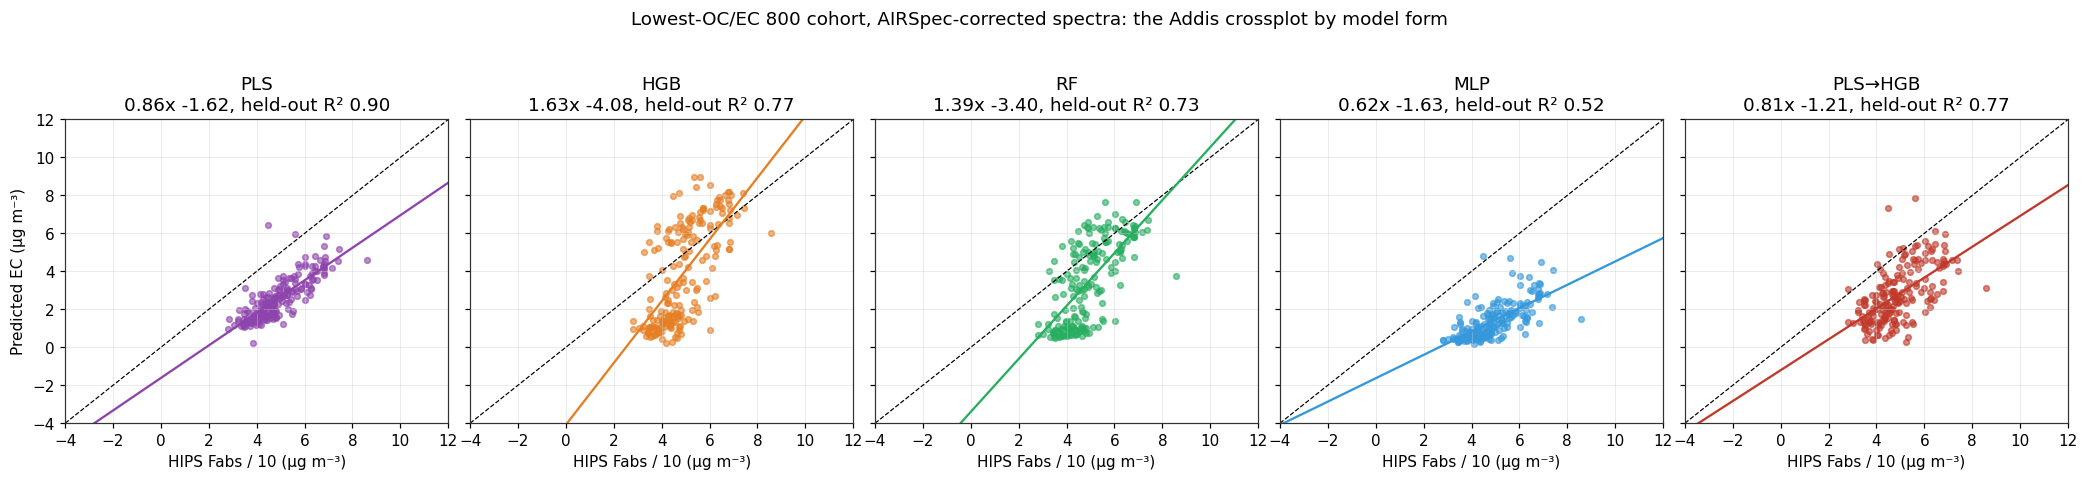

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(19, 4.2), sharex=True, sharey=True)
preds_800 = predictions[('lowest-OC/EC 800', 'corrected')]
sub = results[(results['cohort'] == 'lowest-OC/EC 800') & (results['representation'] == 'corrected')].set_index('model')
lim = (-4, 12)
for ax, name in zip(axes, COLORS):
    pred = preds_800[name][fixed_mask]
    ax.scatter(hips_ec[fixed_mask], pred, s=14, alpha=.6, color=COLORS[name])
    ax.plot(lim, lim, color='black', lw=.8, ls='--')
    xs = np.array(lim)
    ax.plot(xs, sub.loc[name, 'addis_slope'] * xs + sub.loc[name, 'addis_intercept'], color=COLORS[name], lw=1.5)
    ax.set(xlim=lim, ylim=lim, xlabel='HIPS Fabs / 10 (µg m⁻³)',
           title=f"{name}\n{sub.loc[name, 'addis_slope']:.2f}x {sub.loc[name, 'addis_intercept']:+.2f}, "
                 f"held-out R² {sub.loc[name, 'heldout_R2']:.2f}")
axes[0].set_ylabel('Predicted EC (µg m⁻³)')
fig.suptitle('Lowest-OC/EC 800 cohort, AIRSpec-corrected spectra: the Addis crossplot by model form', y=1.03)
fig.tight_layout()
fig.savefig(PLOTS / 'addis_crossplot_by_model_form.png', bbox_inches='tight')
plt.show()

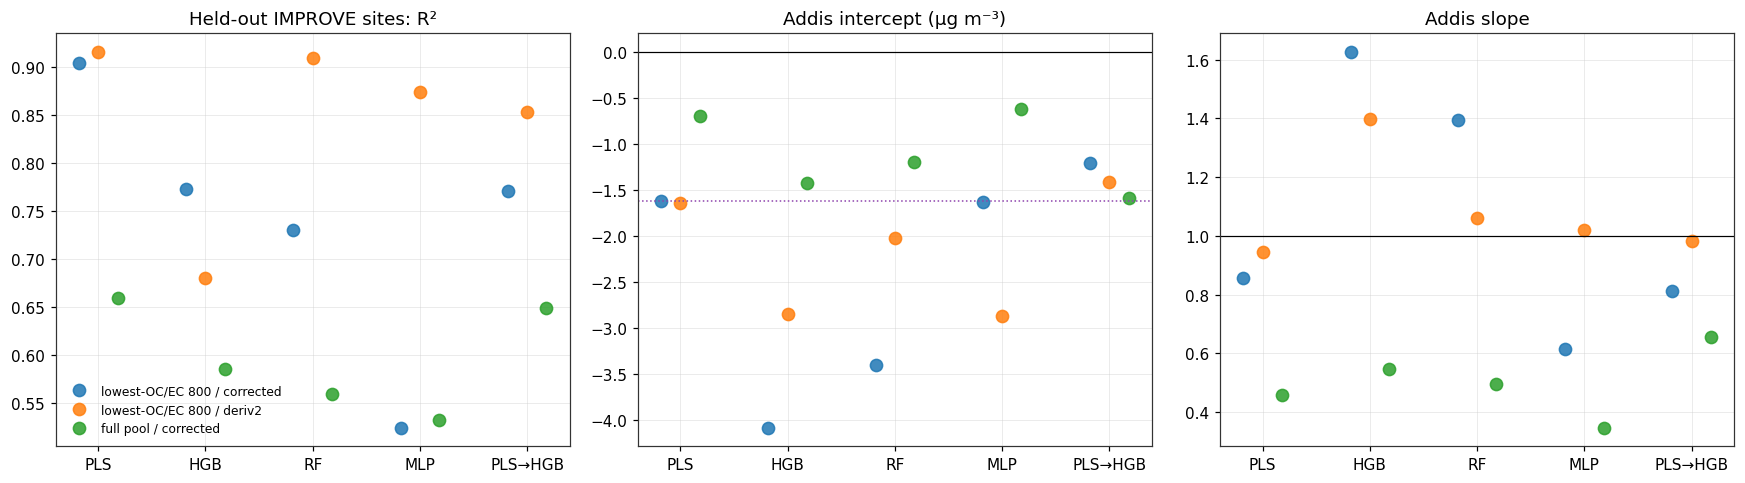

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = list(COLORS)
for ax, metric, title in zip(axes,
                             ['heldout_R2', 'addis_intercept', 'addis_slope'],
                             ['Held-out IMPROVE sites: R²', 'Addis intercept (µg m⁻³)', 'Addis slope']):
    for j, (label, ids, rep) in enumerate(FAMILIES):
        frame = results[(results['cohort'] == label) & (results['representation'] == rep)].set_index('model')
        ax.plot(np.arange(len(order)) + (j - 1) * .18, frame.loc[order, metric], 'o',
                ms=8, alpha=.85, label=f'{label} / {rep}')
    if metric == 'addis_intercept':
        ax.axhline(0, color='black', lw=.8)
        ax.axhline(locked['addis_intercept'], color=COLORS['PLS'], lw=1, ls=':', label='locked PLS')
    if metric == 'addis_slope':
        ax.axhline(1, color='black', lw=.8)
    ax.set(xticks=range(len(order)), xticklabels=order, title=title)
axes[0].legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(PLOTS / 'model_form_metrics.png', bbox_inches='tight')
plt.show()

## 2. Labelled extrapolation tests inside IMPROVE

Addis has no labels, so the only place a model's extrapolation behaviour can be *scored*
is inside the network. Three holdouts, all on the full pool with corrected spectra, each
trained on everything else (no site restriction — the tests isolate compositional,
spectral-edge and range extrapolation from site shift):

- **A — the low-OC/EC corner:** hold out the 800 lowest-OC/EC filters, train on the rest.
  This is the network's closest analogue of the Addis position (OC/EC below the range).
- **B — the spectral edge:** hold out the 5% of filters with the largest PCA-10 D² from
  the rest of the pool.
- **C — the loading edge:** hold out the 5% highest EC loadings.

Each is scored by RMSE / R² / slope on the held-out slice, alongside the in-domain
protocol score from §1 for reference.

In [8]:
X_full = spectra_for(ids_full)
y_full = pool.loc[ids_full, 'EC_TOR'].to_numpy(float)
s_full = pool.loc[ids_full, 'Site'].to_numpy()
oc_ec_full = (pool.loc[ids_full, 'OC_TOR'] / pool.loc[ids_full, 'EC_TOR']).to_numpy(float)
k_full = int(results[(results['cohort'] == 'full pool') & (results['model'] == 'PLS')]['k_pls'].iloc[0])

in_800 = np.isin(ids_full, ids_800)
_, d2_all = pca_d2(X_full, X_full)
edge = d2_all >= np.quantile(d2_all, .95)
heavy = y_full >= np.quantile(y_full, .95)
TESTS = {
    'A: low-OC/EC corner (800 held out)': in_800,
    'B: spectral edge (top 5% PCA D²)': edge,
    'C: loading edge (top 5% EC)': heavy,
}
ext_rows, ext_preds = [], {}
for test, mask in TESTS.items():
    for name, model in make_models(k_full, HGB_PARAMS).items():
        model.fit(X_full[~mask], y_full[~mask])
        pred = model.predict(X_full[mask]).ravel()
        m = regression_metrics(y_full[mask], pred)
        ext_rows.append({'test': test, 'model': name, 'n_test': int(mask.sum()),
                         'RMSE_ug': m['RMSE'], 'R2': m['R2'], 'slope': m['slope'],
                         'intercept_ug': m['intercept'], 'bias_ug': m['bias'],
                         'test_median_y_ug': float(np.median(y_full[mask])),
                         'test_median_ocec': float(np.median(oc_ec_full[mask]))})
        ext_preds[(test, name)] = pred
    print(f'{test}: n={mask.sum()}  ' + '  '.join(f"{r['model']} RMSE {r['RMSE_ug']:.2f}" for r in ext_rows[-5:]))
extrap = pd.DataFrame(ext_rows)
extrap.to_csv(OUT / 'labelled_extrapolation_tests.csv', index=False)
display(extrap.round(3))

A: low-OC/EC corner (800 held out): n=800  PLS RMSE 12.24  HGB RMSE 13.71  RF RMSE 12.46  MLP RMSE 12.62  PLS→HGB RMSE 13.29


B: spectral edge (top 5% PCA D²): n=651  PLS RMSE 18.21  HGB RMSE 24.75  RF RMSE 24.18  MLP RMSE 25.92  PLS→HGB RMSE 23.65


C: loading edge (top 5% EC): n=654  PLS RMSE 26.71  HGB RMSE 35.79  RF RMSE 36.51  MLP RMSE 30.73  PLS→HGB RMSE 35.76


,test,model,n_test,RMSE_ug,R2,slope,intercept_ug,bias_ug,test_median_y_ug,test_median_ocec
0,A: low-OC/EC corner (800 held out),PLS,800,12.236,0.769,0.343,2.120,-3.185,2.798,1.857
1,A: low-OC/EC corner (800 held out),HGB,800,13.706,0.660,0.262,2.137,-3.820,2.798,1.857
2,A: low-OC/EC corner (800 held out),RF,800,12.462,0.792,0.339,1.389,-3.949,2.798,1.857
3,A: low-OC/EC corner (800 held out),MLP,800,12.619,0.767,0.332,1.410,-3.983,2.798,1.857
4,A: low-OC/EC corner (800 held out),PLS→HGB,800,13.286,0.532,0.308,2.663,-2.921,2.798,1.857
5,B: spectral edge (top 5% PCA D²),PLS,651,18.209,0.650,0.806,4.142,1.115,8.946,5.792
6,B: spectral edge (top 5% PCA D²),HGB,651,24.748,0.314,0.215,12.909,0.639,8.946,5.792
7,B: spectral edge (top 5% PCA D²),RF,651,24.176,0.338,0.266,14.024,2.551,8.946,5.792
8,B: spectral edge (top 5% PCA D²),MLP,651,25.916,0.453,0.779,5.629,2.175,8.946,5.792
9,B: spectral edge (top 5% PCA D²),PLS→HGB,651,23.650,0.412,0.247,10.965,-0.817,8.946,5.792


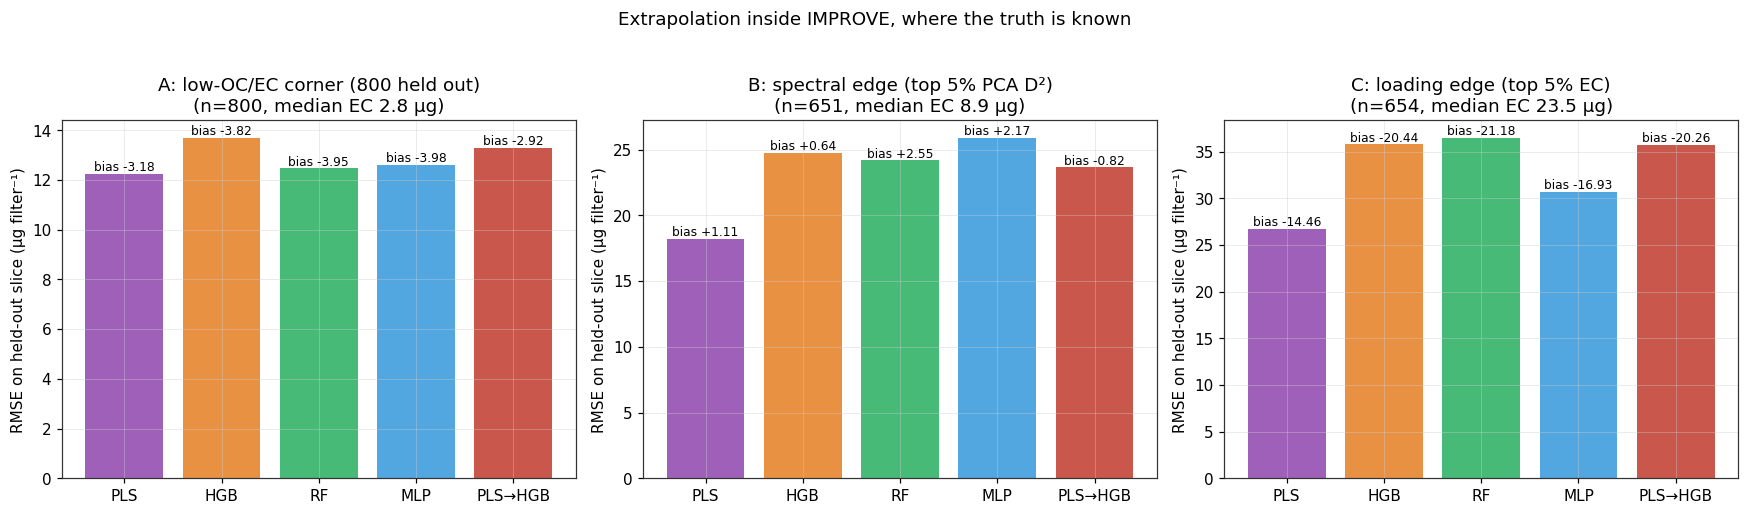

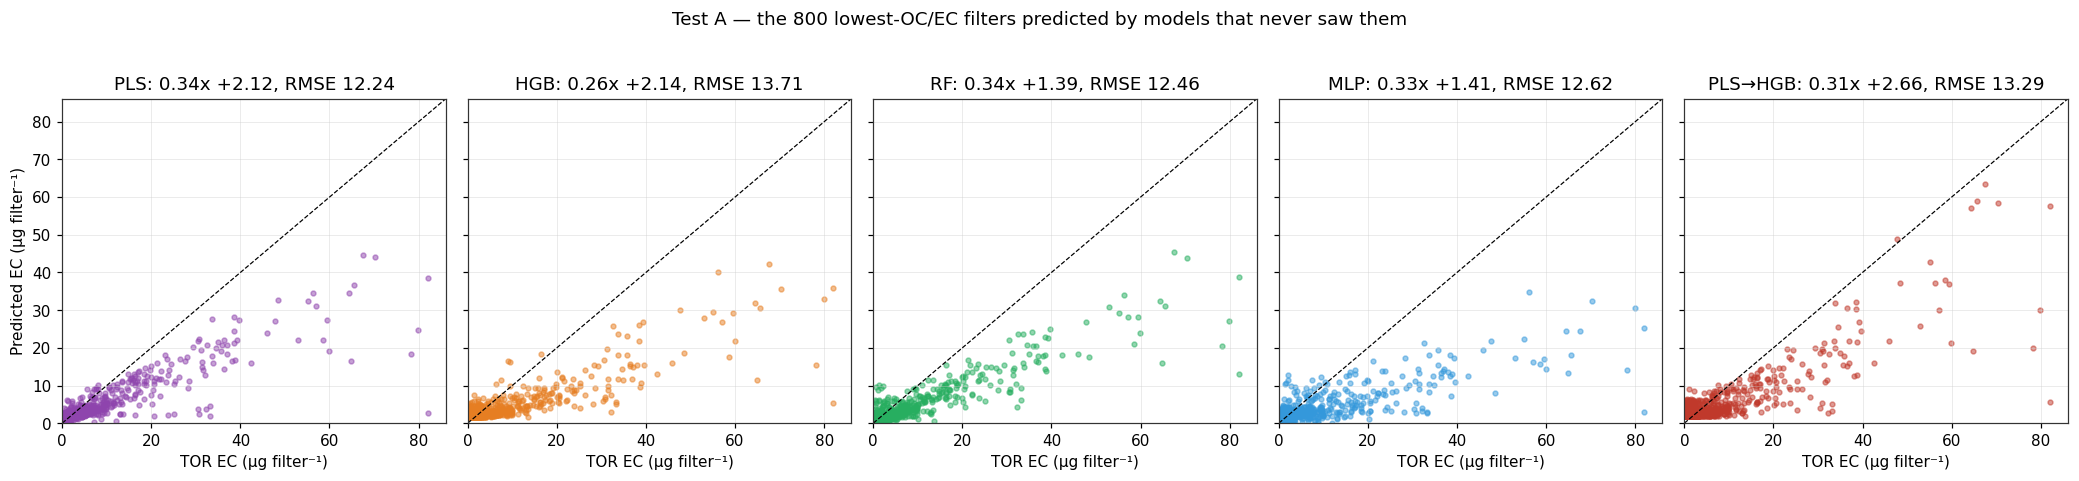

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, (test, mask) in zip(axes, TESTS.items()):
    frame = extrap[extrap['test'] == test].set_index('model').loc[order]
    ax.bar(order, frame['RMSE_ug'], color=[COLORS[m] for m in order], alpha=.85)
    for i, (rmse, bias) in enumerate(zip(frame['RMSE_ug'], frame['bias_ug'])):
        ax.text(i, rmse, f'bias {bias:+.2f}', ha='center', va='bottom', fontsize=8)
    ax.set(title=f'{test}\n(n={mask.sum()}, median EC {np.median(y_full[mask]):.1f} µg)', ylabel='RMSE on held-out slice (µg filter⁻¹)')
fig.suptitle('Extrapolation inside IMPROVE, where the truth is known', y=1.03)
fig.tight_layout()
fig.savefig(PLOTS / 'labelled_extrapolation_rmse.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(19, 4.2), sharex=True, sharey=True)
test_a = 'A: low-OC/EC corner (800 held out)'
mask_a = TESTS[test_a]
lim = (0, float(np.quantile(y_full[mask_a], .995)) * 1.05)
for ax, name in zip(axes, order):
    ax.scatter(y_full[mask_a], ext_preds[(test_a, name)], s=10, alpha=.5, color=COLORS[name])
    ax.plot(lim, lim, color='black', lw=.8, ls='--')
    row = extrap[(extrap['test'] == test_a) & (extrap['model'] == name)].iloc[0]
    ax.set(xlim=lim, ylim=lim, xlabel='TOR EC (µg filter⁻¹)',
           title=f"{name}: {row['slope']:.2f}x {row['intercept_ug']:+.2f}, RMSE {row['RMSE_ug']:.2f}")
axes[0].set_ylabel('Predicted EC (µg filter⁻¹)')
fig.suptitle('Test A — the 800 lowest-OC/EC filters predicted by models that never saw them', y=1.03)
fig.tight_layout()
fig.savefig(PLOTS / 'test_a_low_ocec_crossplots.png', bbox_inches='tight')
plt.show()

## 3. Diagnosability: what each model form tells you when it is off-domain

The practical objection to a black box is not that it is wrong but that it fails
silently. Two checks on the 800-cohort models (corrected spectra):

1. **Does the prediction respond to distance?** Spearman correlation between the Addis
   prediction (and the residual against Fabs/10) and the model-agnostic PCA D². A linear
   model's output keeps moving as a spectrum leaves the training cloud; a tree ensemble's
   output saturates inside the training range of *y* however far the spectrum is.
2. **Is there a model-internal warning?** PLS has its own score-space D²; the random
   forest has per-tree spread. Both are compared with the PCA D².

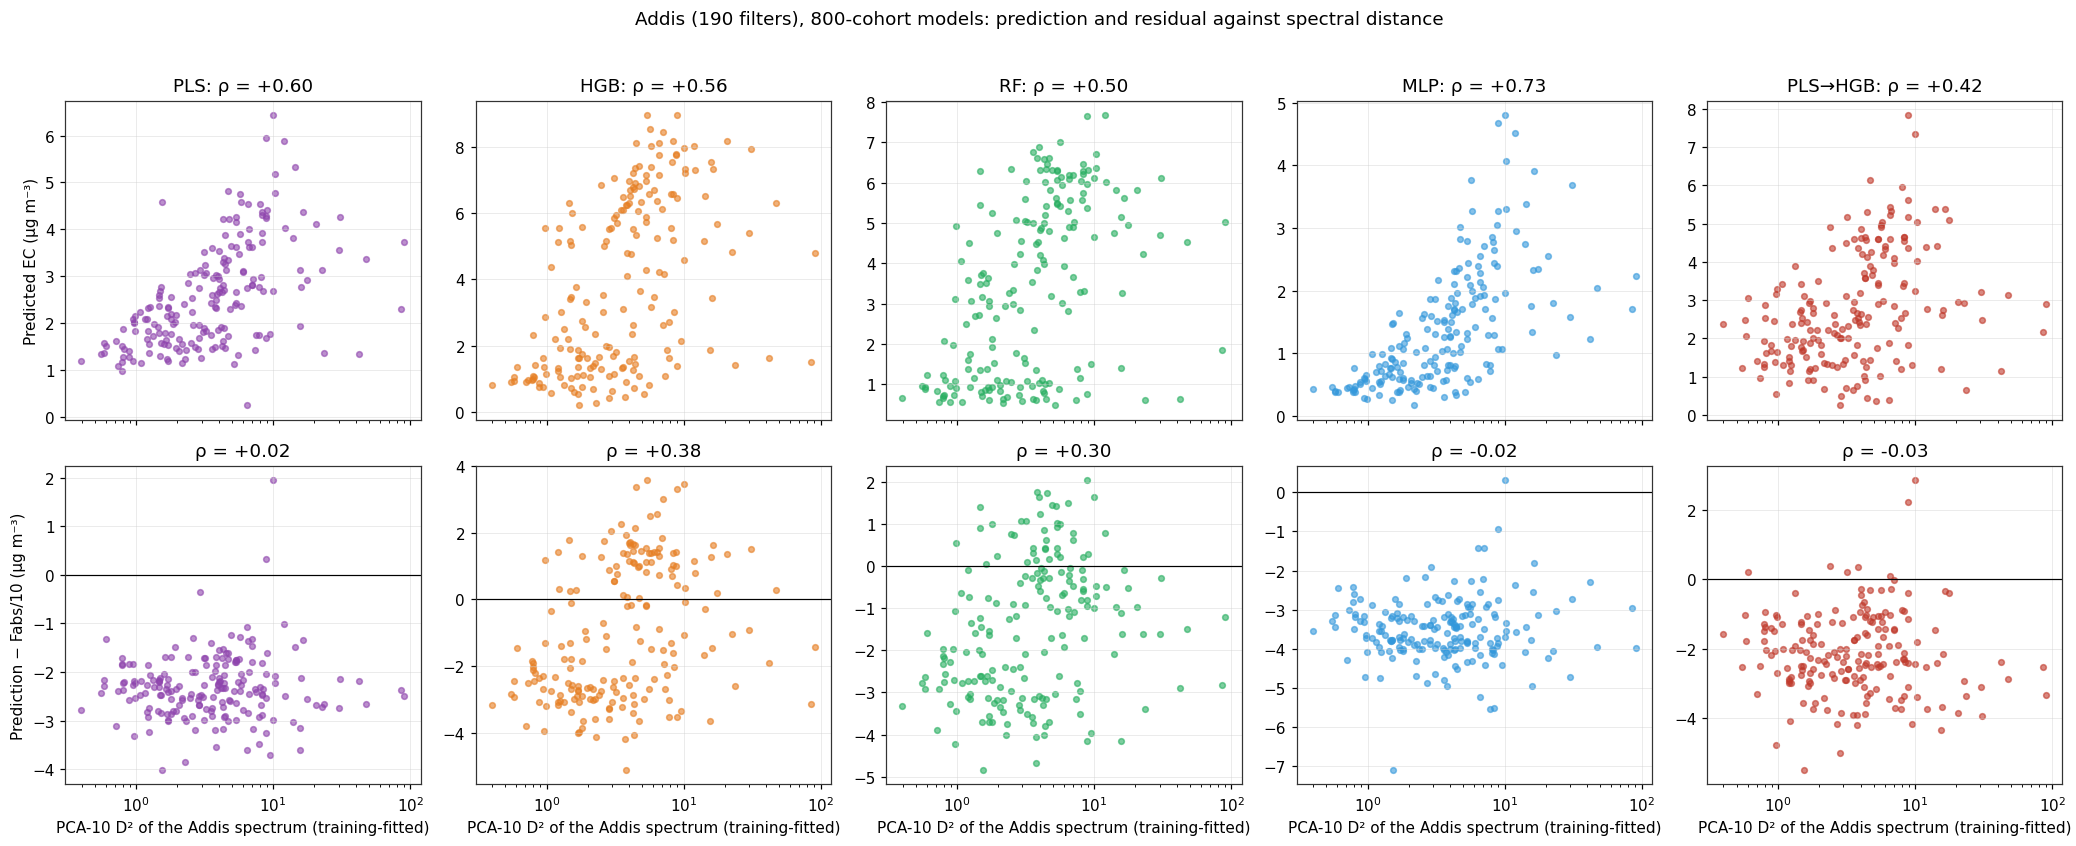

,PCA D²,PLS score-space D²,RF tree spread (µg m⁻³)
PCA D²,1.000,0.743,0.355
PLS score-space D²,0.743,1.000,0.456
RF tree spread (µg m⁻³),0.355,0.456,1.000


Addis filters beyond the training p95: PCA D² 4%, PLS D² 1%


In [10]:
d2_pca = preds_800['_pca_d2']
d2_pls = preds_800['_pls_d2']
rf_spread = preds_800['_rf_spread']
fig, axes = plt.subplots(2, 5, figsize=(19, 7.5), sharex=True)
for j, name in enumerate(order):
    pred = preds_800[name]
    resid = pred - hips_ec
    for i, (y_plot, ylabel) in enumerate([(pred, 'Predicted EC (µg m⁻³)'), (resid, 'Prediction − Fabs/10 (µg m⁻³)')]):
        ax = axes[i, j]
        ax.scatter(d2_pca[fixed_mask], y_plot[fixed_mask], s=14, alpha=.6, color=COLORS[name])
        rho = spearmanr(d2_pca[fixed_mask], y_plot[fixed_mask]).statistic
        ax.set(xscale='log', title=f'{name}: ρ = {rho:+.2f}' if i == 0 else f'ρ = {rho:+.2f}')
        if i == 1:
            ax.axhline(0, color='black', lw=.8)
            ax.set_xlabel('PCA-10 D² of the Addis spectrum (training-fitted)')
        if j == 0:
            ax.set_ylabel(ylabel)
fig.suptitle('Addis (190 filters), 800-cohort models: prediction and residual against spectral distance', y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / 'addis_prediction_vs_d2_by_model.png', bbox_inches='tight')
plt.show()

diag = pd.DataFrame({
    'PCA D²': d2_pca[fixed_mask], 'PLS score-space D²': d2_pls[fixed_mask], 'RF tree spread (µg m⁻³)': rf_spread[fixed_mask],
})
diag_corr = diag.corr(method='spearman')
diag_corr.to_csv(OUT / 'addis_domain_diagnostics_spearman.csv')
display(diag_corr.round(3))
print(f"Addis filters beyond the training p95: PCA D² {locked['addis_share_beyond_pca_p95']:.0%}, "
      f"PLS D² {locked['addis_share_beyond_pls_p95']:.0%}")

In [11]:
summary = results[show_cols + ['spearman_resid_vs_plsD2', 'spearman_rf_spread_vs_pcaD2']].copy()
summary.to_csv(OUT / 'summary_for_readme.csv', index=False)
display(summary.round(3))

,cohort,representation,model,k_pls,heldout_R2,heldout_RMSE_ug,addis_slope,addis_intercept,addis_RMSE_ugm3,addis_median_pred_ugm3,addis_share_negative,spearman_resid_vs_pcaD2,spearman_pred_vs_pcaD2,spearman_resid_vs_plsD2,spearman_rf_spread_vs_pcaD2
0,lowest-OC/EC 800,corrected,PLS,5,0.904,3.859,0.857,-1.615,2.410,2.358,0.0,0.020,0.601,-0.055,NaN
1,lowest-OC/EC 800,corrected,HGB,5,0.773,5.919,1.627,-4.083,2.284,3.419,0.0,0.378,0.563,NaN,NaN
2,lowest-OC/EC 800,corrected,RF,5,0.730,6.191,1.394,-3.401,2.200,3.409,0.0,0.299,0.500,NaN,0.355
3,lowest-OC/EC 800,corrected,MLP,5,0.525,7.835,0.615,-1.632,3.604,1.091,0.0,-0.018,0.731,NaN,NaN
4,lowest-OC/EC 800,corrected,PLS→HGB,5,0.771,5.587,0.813,-1.208,2.440,2.537,0.0,-0.033,0.420,NaN,NaN
5,lowest-OC/EC 800,deriv2,PLS,2,0.916,5.384,0.944,-1.645,2.053,2.596,0.0,-0.024,0.576,0.275,NaN
6,lowest-OC/EC 800,deriv2,HGB,2,0.680,6.912,1.398,-2.849,1.535,3.134,0.0,0.345,0.566,NaN,NaN
7,lowest-OC/EC 800,deriv2,RF,2,0.909,4.564,1.060,-2.023,1.884,2.749,0.0,0.303,0.656,NaN,0.637
8,lowest-OC/EC 800,deriv2,MLP,2,0.874,5.265,1.020,-2.870,2.886,1.720,0.0,0.319,0.670,NaN,NaN
9,lowest-OC/EC 800,deriv2,PLS→HGB,2,0.854,4.534,0.983,-1.411,2.312,2.722,0.0,-0.067,0.472,NaN,NaN


## Takeaways

- **In-domain, PLS is the ceiling for these spectra.** No nonlinear form beats it on the
  protocol's held-out sites in any cohort or representation. The one near-tie (random
  forest on second derivatives, 0.909 vs 0.916) comes with a steeper Addis slope and a
  more negative intercept, not a better one.
- **The Addis sign is model-form independent.** Fifteen fits, fifteen negative intercepts
  (−0.6 to −4.1 µg m⁻³). The compositional argument to reviewers does not rest on PLS.
  Tree ensembles on corrected spectra reproduce the *raw*-model geometry (≈1.4–1.6x,
  −3 to −4), which is worth remembering if anyone proposes "just use LightGBM".
- **Labelled extrapolation is the decisive evidence, and it favours PLS.** Trees saturate
  inside the training range of y (test C slope 0.01–0.02) and lose slope at the spectral
  edge (test B 0.2–0.3 vs 0.81); the network's own low-OC/EC corner (test A) is hard for
  every form in the same direction — under-prediction with slope ≈0.3 — which is a
  labelled, in-network echo of the Addis offset.
- **Distance diagnostics are not PLS-specific, saturation is.** PCA D² can be computed
  for any model. What a tree cannot do is keep moving as the spectrum leaves the cloud,
  so an off-domain filter gets an in-range answer with no residual trend to catch it.
  Random-forest spread is a weak substitute (ρ 0.36 with D²).
- **Not done here, deliberately:** no hyperparameter search on the full pool, no CNN, no
  Gaussian process, no target labels touched. The HGB grid was chosen on the 800 cohort by
  site-grouped CV and carried forward. A 1-D CNN would need torch (not in the env) and,
  on 800 spectra, would be a data-starved version of the MLP result.
- **What actually moves the open question** is unchanged: Addis labels (Adama TOR
  pairing, ChemSpec_EC provenance, the quartz-TOR campaign in ftir_40). Model form is now
  a closed item.